# Predicting house price using machine learning

## Problem Definition
Given house metrics such as population, median income, and median housing price, can we predict the house price?

This notebook walks through a complete ML workflow:
1. **Explore** the data
2. **Split** data into train / test sets
3. **Clean** the data
4. **Train & evaluate** three models (Linear Regression → Decision Tree → Random Forest)
5. **Cross-validate** to get honest error estimates
6. **Tune** hyperparameters with GridSearchCV
7. **Final evaluation** on the test data set

## Using Pandas to Get Familiar With Our Data

The first step in any machine learning project is familiarize ourselves with the data. We'll use the **Pandas** library for this. Pandas is the primary tool we can use for exploring and manipulating data. Most people abbreviate pandas in their code as `pd`. We do this with the command

In [1]:
import pandas as pd
import numpy as np

The most important part of the Pandas library is the DataFrame. A DataFrame holds the type of data we might think of as a table. This is similar to a sheet in Excel or a table in a SQL database.

Pandas has powerful methods for most things we'll want to do with this type of data.

As an example, we'll look at data about home prices in California, USA.

The example (California) data is at the file path ./datasets/housing/california_data.csv.

We load and explore the data with the following commands:

In [2]:
import os

def load_housing_data(housing_path="./datasets/housing/"):
    csv_path = os.path.join(housing_path, "california_data.csv")
    return pd.read_csv(csv_path)

In [3]:
# returns a pandas DataFrame object containing all the data.
housing = load_housing_data()

# display the top five rows using the DataFrame’s head() method
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Each row represents one **district**. There are 10 attributes (we can see the first 6 in the screenshot): longitude, latitude, housing_median_age, total_rooms, total_bedrooms, population, households, median_income, median_house_value, and ocean_proximity.
    
District is the smallest geographical unit for which the US Census Bureau publishes sample data (a block group typically has a population of 600 to 3,000 people). 

The info() method is useful to get a quick description of the data, in particular, the total number of rows, each attribute’s type, and the number of nonnull values

In [4]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


There are 20,640 instances in the dataset, which means that it is fairly small by Machine Learning standards, but it’s perfect to get started. Notice that the total_bedrooms attribute has only 20,433 nonnull values, meaning that 207 districts are missing this feature. 207 out of 20,640 rows (~1%) have missing `total_bedrooms`. This is small, but ignoring it would crash most ML algorithms.  We will need to take care of this later.

To identify missing values programmatically (instead of checking one column manually), we can compute:
- the number of missing values per column
- the percentage of rows missing in each column

This gives us a quick summary of where data cleaning is needed most.

In [6]:
# Programmatically identify columns with missing values and their percentages
missing_count = housing.isnull().sum()
missing_pct = (missing_count / len(housing) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percentage": missing_pct,
})

# Keep only columns that actually have missing values, sorted by highest percentage
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values(
    by="missing_percentage", ascending=False
)

missing_summary

,missing_count,missing_percentage
total_bedrooms,207,1.0


All attributes are numerical, except the ocean_proximity field. Its type is object, so it could hold any kind of Python object (it is a text attribute). When we looked at the top five rows, we probably noticed that the values in the ocean_proximity column were repetitive, which means that it is probably a categorical attribute.

Before we inspect categories, it is useful to programmatically separate numerical and categorical columns using dtypes:
- Numerical columns usually have dtype `int64` or `float64`
- Categorical/text columns are often `object` (or `category`)

We can use `select_dtypes()` to list each group of columns.

In [7]:
# Identify numerical and categorical columns using dtypes
num_cols = housing.select_dtypes(include=["number"]).columns
cat_cols = housing.select_dtypes(include=["object", "str"]).columns

print("Numerical columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))

Numerical columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Categorical columns: ['ocean_proximity']


In [8]:
for col in cat_cols:
    print(f"\nValue counts for {col}:")
    print(housing[col].value_counts())


Value counts for ocean_proximity:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


Let’s look at the other fields. The describe() method shows a summary of the numerical attributes

In [10]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Interpreting Data Description

The count, mean, min, and max rows are self-explanatory. Note that the null values are ignored (so, for example, the count of total_bedrooms is 20,433, not 20,640). The std row shows the standard deviation, which measures how dispersed the values are. The 25%, 50%, and 75% rows show the corresponding percentiles: a percentile indicates the value below which a given percentage of observations in a group of observations fall. For example, 25% of the districts have a housing_median_age lower than 18, while 50% are lower than 29 and 75% are lower than 37. These are often called the 25th percentile (or first quartile), the median, and the 75th percentile (or third
quartile).

### Plotting Data
Another quick way to get a feel of the type of data we are dealing with is to plot a histogram for each numerical attribute. A histogram shows the number of instances (on the vertical axis) that have a given value range (on the horizontal axis). We can either plot this one attribute at a time, or we can call the hist() method on the whole dataset, and it will plot a histogram for each numerical attribute

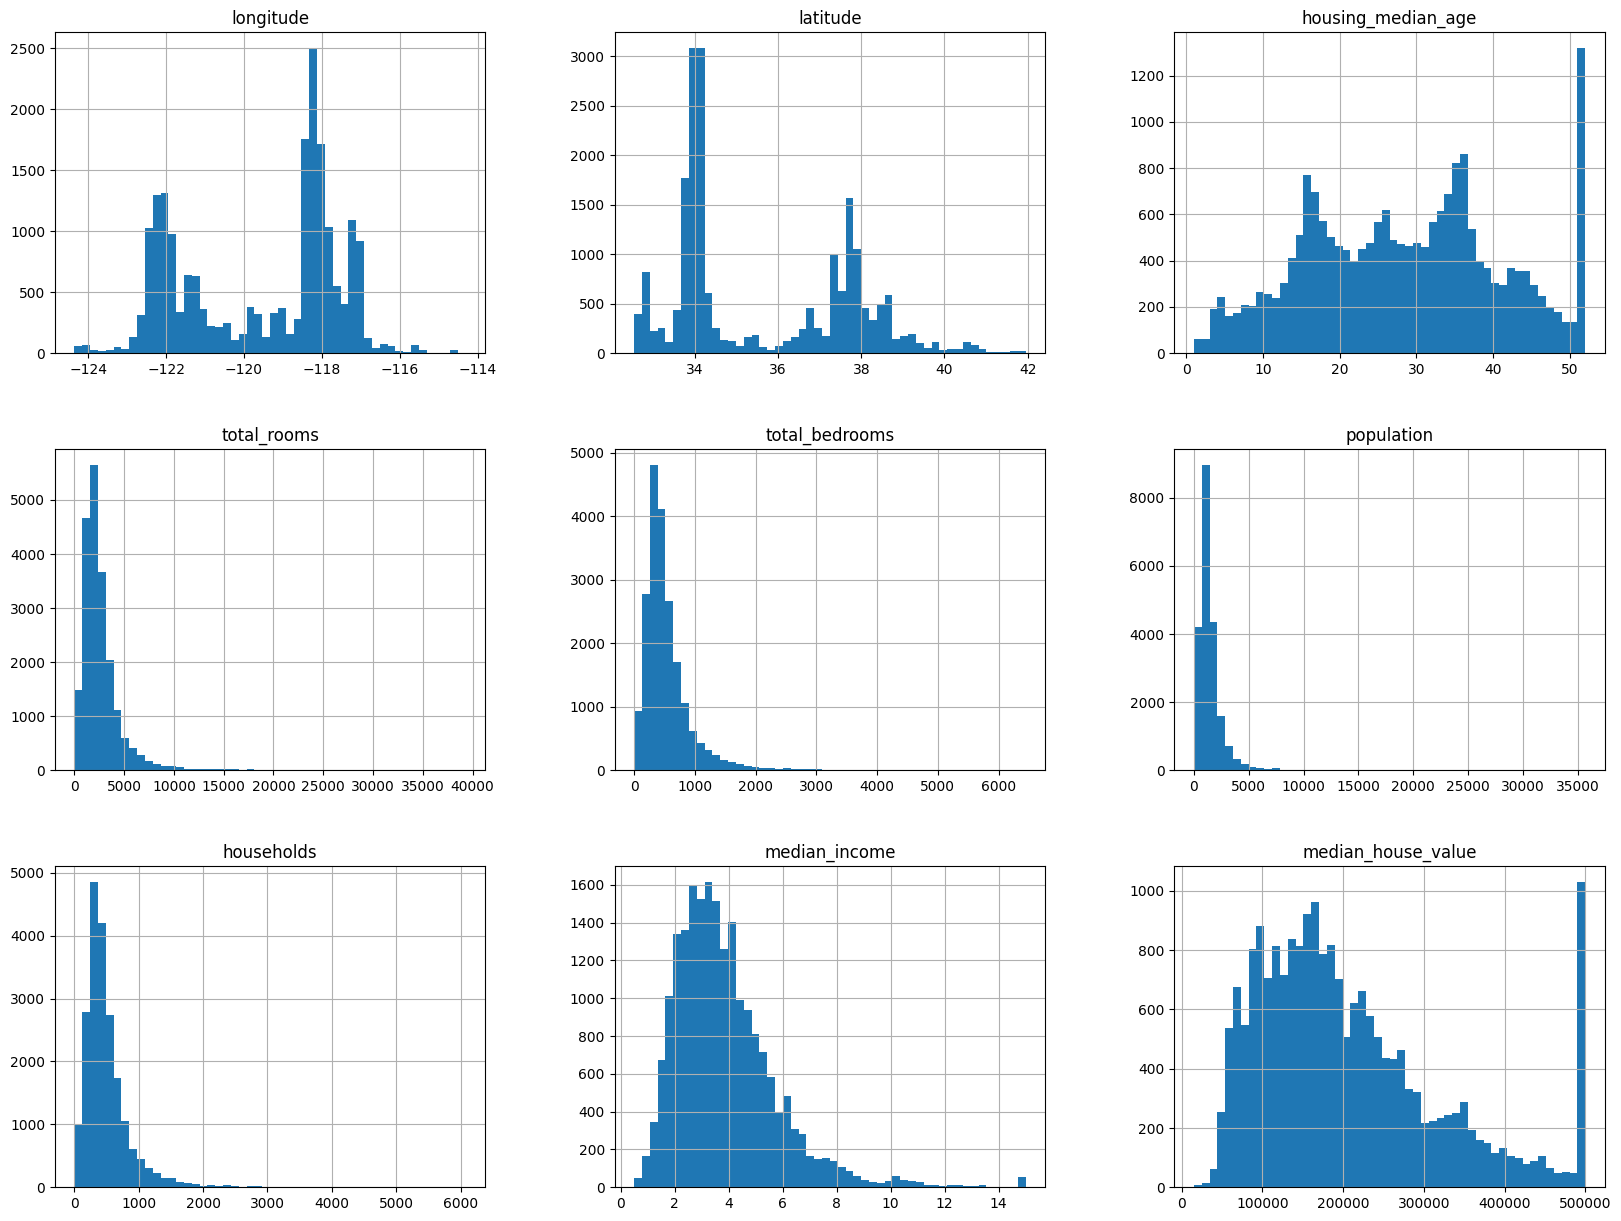

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))
plt.show()

There are a few things we need notice

1. The median income attribute has been scaled and capped at 15 (actually, 15.0001) for higher median incomes, and at 0.5 for lower median incomes. The numbers represent roughly tens of thousands of dollars (e.g., 3 actually means about \$30,000).
2. The housing median age and the median house value were also capped. The latter may be a serious problem since it is our target attribute (our labels). We may learn that prices never go beyond that limit. We need to check with our client team to see if this is a problem or not. If they tell us that they need precise predictions even beyond \$500,000, then we have two options:
      - Collect proper labels for the districts whose labels were capped.
      - Remove those districts from the training set (and also from the test set, since our system should not be evaluated poorly if it predicts values beyond \$500,000).
3. These attributes have very different scales. We will discuss this later, when we explore feature scaling.
4. Finally, many histograms are tail-heavy: they extend much farther to the right of the median than to the left. This may make it a bit harder for some Machine Learning algorithms to detect patterns. We will try transforming these attributes later on to have more bell-shaped distributions.

## Create a Test Set

Creating a test set allows us to validate the model against fresh data, which is essential for avoiding data snooping bias and detecting overfitting. Creating a test set is theoretically simple: pick some instances randomly, typically
20% of the dataset (or less if our dataset is very large), and set them aside.

In practice, we usually use Scikit-Learn's `train_test_split`, which shuffles the rows and splits the dataset for us in one step.

In [12]:
from sklearn.model_selection import train_test_split

The test set simulates "the real world." We must **never** use it during training or hyperparameter tuning — otherwise our error estimates become optimistically biased. 

### Some explanation of the code:

1. `train_test_split(housing, test_size=0.2, random_state=42)`
   This function is Scikit-Learn's standard way to split data into training and test sets.
   - `housing`: the dataset we want to split.
   - `test_size=0.2`: reserves 20% of the rows for the test set and keeps the other 80% for training.
   - `random_state=42`: fixes the random seed so the split is reproducible each time we run the notebook.

2. Shuffling
   By default, `train_test_split()` shuffles the rows before splitting them. This helps ensure the training and test sets are mixed rather than taking one block of rows from the top or bottom of the dataset.

3. Returned values
   The function returns the split datasets in order. Since we are splitting a single DataFrame here, it returns two outputs:
   - `train_set`: the rows used for training
   - `test_set`: the rows held back for final evaluation

We can then use `train_test_split()` like this.

In [13]:
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

In [14]:
len(train_set)

16512

In [15]:
len(test_set)

4128

In [16]:
housing = train_set.drop("median_house_value", axis=1)
housing_labels = train_set["median_house_value"].copy()

The `train_test_split` function from Scikit-Learn is flexible. It simply takes one or more arrays and splits them according to the `test_size`.

| Usage | Example | When to use |
|-------|---------|-------------|
| Splits a **single DataFrame** (`housing`) into two smaller DataFrames | `train_set, test_set = train_test_split(housing, ...)` | Use this if you want to keep your features and labels together for further cleaning or exploration. |
| Splits **two arrays** (`X` and `y`) into four pieces simultaneously | `X_train, X_test, y_train, y_test = train_test_split(X, y, ...)` | Use this if you have already separated your features from your target variable and are ready to train a model. |

## Data Cleaning
Most Machine Learning algorithms cannot work with missing features, so we need to handle missing values before training a model.

In this dataset, we must consider two kinds of attributes:
- Numerical attributes such as total_bedrooms
- Categorical attributes such as ocean_proximity

These two types usually require **different missing-value strategies**.

### Handling Missing Numerical Values
We saw earlier that the total_bedrooms attribute has some missing values, so let’s fix this first. 

For numerical attributes, a common strategy is to replace missing values with the median of each column. Scikit-Learn provides the SimpleImputer class for this.

In [17]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")

Since the median can only be computed on numerical attributes, we need to create a copy of the data that contains only the numerical columns.

In [18]:
housing_num = housing.select_dtypes(include=["number"]).copy()

Now we can fit the imputer instance to the training data using the fit() method. `fit` is to learn parameters from the data.

In [21]:
num_imputer.fit(housing_num)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


The imputer has simply computed the median of each attribute and stored the result in its statistics_ instance variable.

In [22]:
num_imputer.statistics_

array([-118.49  ,   34.25  ,   29.    , 2129.    ,  437.    , 1169.    ,
        411.    ,    3.5246])

Now we can use this “trained” imputer to transform the training set by replacing missing values with the learned medians:

In [23]:
X = num_imputer.transform(housing_num)

### Handling Missing Categorical Values
So far, we’ve only dealt with numerical data. Categorical attributes can also have missing values; although our current dataset is complete, we will assume some are missing for demonstration purposes. These must be addressed before they can be encoded.

In this dataset, the main categorical attribute is ocean_proximity. If some rows have missing category values, a common strategy is to replace missing categorical values with:
- the most frequent category, or
- a constant value such as "Unknown"

Here we use the most frequent category:

In [24]:
cat_imputer = SimpleImputer(strategy="most_frequent")
housing_cat = housing.select_dtypes(include=["object", "str"]).copy()
housing_cat_filled = cat_imputer.fit_transform(housing_cat)

Note: fit_transform() combines fit() and transform() into a single step

### Encoding Categorical Attributes

So far we have only dealt with numerical attributes, but now let’s look at text attributes. In this dataset, there is just one: the ocean_proximity attribute. This attribute is a categorical attribute. Most Machine Learning algorithms prefer to work with numbers, so let’s convert these categories from text to numbers. For this, we can use Scikit-Learn’s OneHotEncoder class. 

The OneHotEncoder class creates one binary attribute per category: one attribute equal to 1 when the category is “<1H OCEAN” (and 0 otherwise), another attribute equal to 1 when the category is “INLAND” (and 0 otherwise), and so on. This is called one-hot encoding, because only one attribute will be equal to 1 (hot), while the others will be 0 (cold).

In [25]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()

housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot.toarray()

array([[0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.]], shape=(16512, 5))

We can get the list of categories using the categories_ instance variable. It is a list containing a 1D array of categories for each categorical attribute.

In [26]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

## Transformation Pipelines

In real projects, we usually do not preprocess numerical and categorical attributes separately by hand. Instead, we combine these steps into a preprocessing pipeline. And Scikit-Learn provides the Pipeline class to help with such sequences of transformations. 

### What is a pipeline?
A **pipeline** is a sequence of processing steps chained together into one object.

A Scikit-Learn `Pipeline` usually contains:
1. one or more **transformers** in the earlier steps
2. an optional final **estimator** (for example, a classifier or regressor)

The final step can be a predictive model, while all earlier steps should be transformers.

The Pipeline is built using a list of (key, value) pairs, where the key is a string containing the name you want to give this step and value is an transformer object.

Pipelines bundle preprocessing + model into one object. This is critical for two reasons:
1. **Convenience**: one `.fit()` / `.predict()` call does everything.
2. **Prevents data leakage**: during cross-validation, the scaler/imputer is fit *only* on the training folds, not the validation fold. Without a pipeline, it's easy to accidentally leak test-fold statistics into training.

One of the most important transformations we need to apply to our data is feature scaling. With few exceptions, Machine Learning algorithms don’t perform well when the input numerical attributes have very different scales. This is the case for the housing data: the total number of rooms ranges from about 6 to 39,320, while the median incomes only range from 0 to 15. Scikit-Learn provides a transformer called StandardScaler for feature scaling.

StandardScaler is a scaling technique wherein it makes the data scale-free by converting the statistical distribution of the data into the below format:
- mean - 0 (zero)
- standard deviation - 1

Note: Standardization is only applicable on the data values that follows Normal Distribution.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
('imputer', SimpleImputer(strategy="median")),
('std_scaler', StandardScaler()),
])

Besides the numerical columns, we also have the categorical columns.

In [28]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder())
])

A Scikit-Learn **ColumnTransformer** class allows us to selectively apply data preparation transforms to different columns. This is particularly useful when you have a mix of numerical and categorical data that requires different preprocessing steps.  

ColumnTransformer takes a list of tuples as its primary argument. The general structure of each tuple inside the list is: (name, transformer, columns).
1. The "Name" ("num", "cat")
What it is: A simple string that acts as an identifier for that specific step.
2. The "Transformer" (num_pipeline, cat_pipeline)
What it is: The object that actually performs the data manipulation.
3. The "Columns" (num_attribs, cat_attribs)
What it is: A specification of which columns the transformer should be applied to.

Thus, we should use ColumnTransformer to apply all the transformations to the housing training data.

In [29]:
from sklearn.compose import ColumnTransformer

num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

housing_prepared = preprocessor.fit_transform(housing)

housing_prepared

array([[ 1.17299302, -1.35041487,  0.42853749, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.26802809, -1.37853628, -1.47350948, ...,  0.        ,
         0.        ,  1.        ],
       [-1.3529389 ,  0.98834939, -0.04697426, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 0.11760365,  0.30406165, -0.99799774, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.18799856, -0.72705686, -0.522486  , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.35269038, -0.66144022, -0.522486  , ...,  0.        ,
         0.        ,  0.        ]], shape=(16512, 13))

## Select and Train a Model
We got the data and explored it, we sampled a training set and a test set, and we wrote transformation pipelines to clean up and
prepare our data for Machine Learning algorithms automatically. We are now ready to select and train a Machine Learning model.

Before picking an algorithm, notice what we have from the previous steps:
- **Goal/label**: we are predicting `median_house_value`, which is a **continuous value** ⇒ this is a **regression** task.
- **Model-ready features**: after applying `preprocessor`, we have `housing_prepared` where missing values are handled, numerical features are scaled, and the categorical feature `ocean_proximity` is one-hot encoded.

To connect the data characteristics to model choice, we try three complementary models:
- **Linear Regression**: a simple, fast, and interpretable **baseline**. It helps us check whether a mostly linear relationship (after our feature engineering) is already enough, and it provides a reference RMSE to beat.
- **Decision Tree Regressor**: a non-linear model that can automatically learn **threshold effects** and **feature interactions** (common in real-world housing data). It is more flexible than linear regression, but can easily overfit.
- **Random Forest Regressor**: an **ensemble** of decision trees, which typically generalizes better than a single tree by reducing overfitting. It is often a strong default for tabular data when we suspect non-linearity and interactions.

### First Machine Learning Model - Linear Regression model


In [30]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### 1. Testing Predictions on a Small Sample
The code has finished training. Let’s "sanity check" the model by comparing its predictions against the actual labels for the first five rows of our training set.

In [27]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]

# Use the pre-fitted preprocessor to transform the new data
some_data_prepared = preprocessor.transform(some_data)  

print("Predictions:", lin_reg.predict(some_data_prepared))

Predictions: [288032.98103109 227257.00294643 291933.85619579 265790.85763895
  21816.54279835]


In [28]:
print("Labels:", list(some_labels))

Labels: [291000.0, 156100.0, 353900.0, 241200.0, 53800.0]


**Evaluation:**
The model is functional but produces unreliable results. Individual predictions show high variance. A global metric is required to assess the overall magnitude of these error

#### 2. Measuring Global Performance (RMSE)
We use the Root Mean Squared Error (RMSE) to measure the average magnitude of the error.
- MSE (Mean Squared Error): Great for the computer to minimize during training.
- RMSE: Great for humans to read because it is in the same units as the target (USD).

We will measure this regression model’s RMSE on the whole training set using Scikit-Learn’s mean_squared_error() function.

MSE is mathematically convenient for training models, while RMSE is preferred in real projects because it measures prediction error in the same unit as the target, making it easy to interpret and communicate. For example, House price → RMSE = \\$20,000. Stakeholders understand this immediately. MSE like \\$400,000,000 is meaningless to most people.

In [29]:
from sklearn.metrics import mean_squared_error

housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(68458.01274733282)

It means that a typical prediction error is \\$68,458. Since most districts’ median_housing_values range between \\$120,000 and \\$265,000, this prediction is not very satisfying.  This is an example of a model underfitting the training data. When this happens, it can mean that the features do not provide enough information to make good predictions, or that the model is not powerful enough.

**Underfitting**

Linear Regression training RMSE ≈ **\$68,458.**. This is the error on training data, and it's already high. When the training error itself is bad, the model is **underfitting** — it's too simple to capture the patterns in the data. The fix: use a more complex model (next: Decision Tree).

### Second Machine Learning Model - Decision Tree model
let’s try a more complex model (DecisionTreeRegressor) to see how it does. 

In [30]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(housing_prepared, housing_labels)

housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

np.float64(0.0)

No error at all?! This can happen with a very flexible model like a Decision Tree.

**Important:** this RMSE was computed on the *same training data* the model was fit on (`housing_prepared` / `housing_labels`). So this number is **training error**, not a measure of how well the model will generalize to unseen data.

**Overfitting**

Decision Tree training RMSE = **0.0**. The tree has memorized every single training example perfectly — it created a leaf node for (almost) every data point. This is the most extreme form of **overfitting**.

**Rule of thumb**: if training error is suspiciously perfect, the model is almost certainly overfitting. We need cross-validation to reveal the true performance.

### Cross-Validation
To truly evaluate a model like a Decision Tree, you shouldn't use the training set for prediction. You should use K-Fold Cross-Validation.

During cross-validation, we split the training set into 10 random subsets (which are called folds), trains the model on 9 of them, and evaluates it on the remaining 1. It repeats this 10 times so every piece of data gets used for testing once.

If we run `fit_transform()` on the full dataset before cross-validation, steps like imputation and scaling would learn statistics (medians/means/categories) from the validation fold, which is data leakage.

To fix this, we use a Pipeline. This "glues" the preprocessing and the model into a single object. When Cross-Validation calls this pipeline, it ensures the preprocessor only learns from the training folds and never sees the validation fold.

**Why do we set `random_state=42`?**

Many algorithms contain randomness (e.g., Decision Trees use randomized tie-breaking; Random Forests also use random row/feature sampling). Setting `random_state` fixes the random seed so we can get the same results each run, making comparisons and debugging reproducible. The number `42` is just a commonly used arbitrary seed—you can use any integer.

In [31]:
from sklearn.model_selection import cross_val_score

# 1. Create a Pipeline: Preprocessor + Model
# This ensures fit() only happens on the training folds during CV
tree_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42)),
])

# 2. Run Cross-Validation on the RAW data (not housing_prepared!)
# We use the raw 'housing' features because the pipeline handles the transformation
scores = cross_val_score(
    tree_model,
    housing,
    housing_labels,
    scoring="neg_mean_squared_error",
    cv=10,
 )

# 3. Calculate the RMSE
tree_rmse_scores = np.sqrt(-scores)

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(tree_rmse_scores)

Scores: [68797.86897389 71025.06024625 67497.67483204 67760.89368107
 68170.4349214  67572.60730909 67972.20945675 66637.81518866
 67602.27988007 70597.14981157]
Mean: 68363.39943007694
Standard deviation: 1332.212300197407




Now the Decision Tree doesn’t look as good as it did earlier. In fact, it seems to perform worse than the Linear Regression model! The Decision Tree has a score of approximately 68,363, generally ±1,332.

**Cross-Validation Reveals the Truth**

>| Model | Training RMSE | Cross-Val RMSE |
>|-------|--------------|----------------|
>| Decision Tree | 0 (memorized!) | ~68,363 |

The gap between 0 and ~68K is the **overfitting gap**. Cross-validation told us what the training RMSE hid: this model generalizes *poorly*.

Let’s compute the same cross-validation scores for the Linear Regression model so we can compare models fairly.

In [32]:
lin_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression()),
])

lin_scores = cross_val_score(
    lin_model,
    housing,
    housing_labels,
    scoring="neg_mean_squared_error",
    cv=10,
 )
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [68321.60481688 71621.45529918 66723.0183533  66883.87688114
 70967.76069755 67808.70012254 68145.22005801 67721.97357367
 70146.08142744 67600.88895587]
Mean: 68594.05801855915
Standard deviation: 1620.90325650009


While both models show similar average errors, the Decision Tree exhibits significantly higher variance than the Linear Regression model. This suggests the Tree is sensitive to the training data (overfitting), whereas the Linear Regression is more stable but likely too simple to capture the underlying patterns (underfitting).

**Model Comparison So Far**

| Model | Training RMSE | Cross-Val RMSE (mean) |
|-------|--------------|----------------------|
| Linear Regression | ~68,458 | ~68,594 |
| Decision Tree | 0 | ~68,363 |

Linear Regression: training ≈ CV → **underfitting** (model too simple, consistent but bad).

Decision Tree: training = 0 but CV ≈ 69K → **overfitting** (model memorizes, doesn't generalize).

Neither is satisfying. Let's try Random Forest, which combats overfitting by averaging many trees.

### Third Machine Learning Model - Random Forest model

Let’s try one last model now: the RandomForestRegressor. Random Forests work by training many Decision Trees on random subsets of
the features, then averaging out their predictions.

**Why Random Forest Helps**

A single Decision Tree overfits because it memorizes noise. A Random Forest trains *many* trees, each on a random subset of data and features, then **averages** their predictions. This averaging smooths out individual tree errors and dramatically reduces overfitting.

In [33]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, housing_labels)

housing_predictions = forest_reg.predict(housing_prepared)
forest_mse = mean_squared_error(housing_labels, housing_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse

np.float64(18162.038993189588)

**The 18,162 RMSE is Training Error!**

The Random Forest just scored ~**18,162** RMSE. Looks amazing, right? **Be careful!** This was evaluated on the *same data* used for training (just like the Decision Tree's 0.0). Random Forests with default settings (100 trees, no depth limit) still partially memorize training data.

The cross-validation below will reveal the *honest* generalization score. Watch how different it is!

**!!! Notice**: The code below may take quite a long time to run. If your laptop is not powerful enough, you can skip this step.

In [34]:

forest_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(random_state=42)),
])

forest_scores = cross_val_score(
    forest_model,
    housing,
    housing_labels,
    scoring="neg_mean_squared_error",
    cv=10,
 )
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

Scores: [47924.49942159 49875.72053188 48766.5360811  47054.22152332
 50215.54379069 48465.45329862 49085.12638165 48545.24589326
 49880.16406846 47980.04173608]
Mean: 48779.25527266411
Standard deviation: 952.3236429089108


This result is much better: Random Forests look very promising.

 **The Gap Tells the Story**

| Model | Training RMSE | Cross-Val RMSE (mean) | Overfitting Gap |
|-------|--------------|----------------------|-----------------|
| Linear Regression | ~68,458 | ~68,594 | ~136 (small gap → underfitting) |
| Decision Tree | 0 | ~68,363 | ~68,363 (huge → severe overfitting) |
| Random Forest | ~18,162 | ~48,779 | ~30,617 (moderate → some overfitting) |

Random Forest is our best model so far:
- **CV RMSE ~48,779** beats both Linear Regression (~68,594) and Decision Tree (~68,363).
- The gap of ~30K between training and CV means it's still overfitting somewhat — this is why we tune hyperparameters next.

**Key insight**: The 18,162 number is *not* how well this model performs in the real world. The ~48,779 is.

## Fine-Tune the Model

We note that the score on the training set is still much lower than on the validation sets, meaning that the Random Forest model is still overfitting the training set.  One solution for overfitting is to regularise the model by using hyperparameters.

Manually tuning hyperparameters is tedious and time-consuming. Instead, use Scikit-Learn’s GridSearchCV, which automatically searches for the best combination of hyperparameters by trying specified values and evaluating them using cross-validation.

**What GridSearchCV Does**

GridSearchCV is like a systematic experiment:
1. You define a "grid" of hyperparameter values to try (e.g., "try 3, 10, or 30 trees").
2. It tries every combination. For each combination, it runs cross-validation to get a reliable score (here, 5-fold).
3. It picks the combination with the best average CV score.
4. It retrains on all training data. Once the best settings are found, it trains a final model using the full training set (this is the `refit=True` default), so no data goes to waste.

This automates what would otherwise be dozens of manual experiments.

Key components of GridSearchCV:
- Estimator: The machine learning model to be tuned.
- Param_grid: Dictionary specifying the parameter grid to be searched.
- Scoring: Metric used to evaluate model performance.
- CV: Cross-validation strategy.

In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Pipeline was imported earlier (see the Transformation Pipelines section)

# IMPORTANT: tune a Pipeline(preprocessing + model) to avoid data leakage
forest_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(random_state=42)),
])

# Define the grid of hyperparameters to search over.
# The "model__" prefix tells the Pipeline: "this parameter belongs to the 'model' step."
#
# Grid 1: try 3×4 = 12 combinations (with bootstrap=True, the default)
# Grid 2: try 2×3 = 6 combinations (with bootstrap=False)
# Total: 18 combinations × 5 folds = 90 model trainings
param_grid = [
    {
        "model__n_estimators": [3, 10, 30],      # how many trees in the forest, include the default 100 and go higher
        "model__max_features": [2, 4, 6, 8],     # how many features each tree considers
    },
    {
        "model__bootstrap": [False],              # turn off bootstrap sampling
        "model__n_estimators": [30, 100],           # fewer options here to save time
        "model__max_features": [2, 3, 4],
    },
]

grid_search = GridSearchCV(
    forest_model,              # the model (Pipeline) to tune
    param_grid,                # all the combinations to try
    cv=5,                      # 5-fold cross-validation
    scoring="neg_mean_squared_error",  # metric to optimize (negative because
                                       # sklearn's GridSearchCV is designed to maximize whatever score you give it,
                                       # but MSE should be minimized)
    return_train_score=True,   # also record training scores (useful for spotting overfitting)
 )

# kicks off the entire search
grid_search.fit(housing, housing_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__max_features': [2, 4, ...], 'model__n_estimators': [3, 10, ...]}, {'model__bootstrap': [False], 'model__max_features': [2, 3, ...], 'model__n_estimators': [30, 100]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher

This param_grid tells Scikit-Learn to first evaluate all 3 * 4 = 12 combinations of n_estimators and max_features hyperparameter values specified in the first dict.

Then try all 2 * 3 = 6 combinations of hyperparameter values in the second dict, but this time with the bootstrap hyperparameter set to False instead of True (which is the default value for this hyperparameter).

The grid search will explore 12 + 6 = 18 combinations of RandomForestRegressor hyperparameter values, and it will train each model 5 times (since we are using five fold cross validation). In other words, all in all, there will be 18 * 5 = 90 rounds of training!

The `model__` prefix (with double underscore) is how you tell the Pipeline "this hyperparameter belongs to the step named model." Without it, the Pipeline wouldn't know which step you're tuning.

When `bootstrap=True` (the default), each tree is trained on a random sample with replacement from the training set. This means some data points get picked multiple times, and roughly 37% of the data gets left out of each tree. This left-out portion is what makes each tree slightly different from the others, which is the whole point of a Random Forest — diversity among trees leads to better generalization.

When `bootstrap=False`, every tree sees the exact same full training set. The only randomness left comes from max_features, which forces each tree to consider a random subset of features at each split. So the trees are still somewhat different, but less so.

Here we set bootstrap=False in the second dictionary of param_grid simply to let GridSearchCV test both options and see which one scores better.

**Grid Search Limitations**

Notice the grid only goes up to `n_estimators=30`, while the default Random Forest uses 100 trees. The best estimator from this grid (30 trees, 8 features) is actually *smaller* than the default model. In practice, you'd want to try larger values like [50, 100, 200, 300] — but that takes much longer to run. The grid here is kept small for demo purposes.

**General tips on setting param_grid:**
1. Start coarse, then zoom in. Use a wide range of values with big gaps first (like [10, 100, 500] for n_estimators). Once you see which region performs best, do a second search with finer values around the winner (like [80, 100, 120]).
2. Always include the default values. They're the baseline. If your search doesn't include them, you can't tell whether your tuning actually improved anything.
3. Search around the boundaries. If the best result lands on the edge of your grid (say the highest value you tested), that's a sign you should extend the search further in that direction — the true optimum might be beyond what you tested.
4. Watch the total number of fits. Every combination you add gets multiplied by the number of CV folds. A grid with 100 combinations and cv=5 means 500 model trainings, which can get slow. If the grid gets too large, consider switching to `RandomizedSearchCV`, which samples random combinations instead of trying all of them — it's much faster and often finds near-optimal settings.
5. Tune the parameters that matter most first. For Random Forest, `n_estimators`, `max_features`, and `max_depth` tend to have the biggest impact. Parameters like `min_samples_split` or `min_samples_leaf` are secondary and can be tuned in a follow-up search once the main ones are settled.

## Evaluate Your System on the Test Set

Now is the time to evaluate the final model on the test set. To get the predictors and the labels from your test set, run your full_pipeline to transform the data (call transform(), not fit_transform()—you do not want to fit the test set!), and evaluate the final model on the test set.

Everything before this point used *only* the training set (including cross-validation, which splits the training set internally). Now we open the "sealed exam paper" — the test set — for the first and only time.

Since the Pipeline handles preprocessing, we can call `predict()` directly on the raw test features.

In [36]:
final_model = grid_search.best_estimator_

X_test = test_set.drop("median_house_value", axis=1)
y_test = test_set["median_house_value"].copy()

# With a preprocessing+model pipeline, we can call predict() directly on raw features
final_predictions = final_model.predict(X_test)

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)
final_rmse

np.float64(48811.43026869561)

 **Final RMSE Score**

| Stage | RMSE | What It Measures |
|-------|------|-----------------|
| Linear Regression (training) | ~68,458 | Underfitting baseline |
| Decision Tree (training) | 0 | Memorization (severe overfitting) |
| Random Forest (training) | ~18,113 | Overfitted — **misleadingly optimistic** |
| Decision Tree (10-fold CV) | ~68,363 | Honest estimate — overfitting revealed |
| Linear Regression (10-fold CV) | ~68,549 | Honest estimate — underfitting confirmed |
| Random Forest (10-fold CV) | ~48,779 | Honest estimate — best model so far |
| **Final test set** | **~48,811** | **Real-world performance estimate** |

**Why does 48,811 look "bad" compared to 18,113?**

Because **18,113 is training error** — the model was evaluated on the same data it memorized. It's like grading a student on the exact questions they practiced on. The 48,546 is the **test set error** — truly unseen data — and it's very close to the ~48–50K range we saw in cross-validation, which confirms our model is working correctly.

**The 48,811 RMSE is the only number that matters for real-world deployment.**